# 06 — Causal Forest (CausalForestDML)

| | |
|---|---|
| **Entradas** | `data/causal_forest_train.csv`, `data/causal_forest_test.csv` |
| **Saídas** | `figs/cf_cate_distribuicao.png`, `cf_gates.png`, `cf_pdp_tau.png`, `cf_feature_importance.png`, `cf_shap_summary.png`; `data/cf_models/cf_final_{p70,p75,p80}.pkl`; 3 linhas em `data/metricas_comparativo.csv` |
| **Ordem** | 6º — independente de GAM e BSTS; depende apenas do notebook 01 |

**Modos de execução:**
- `CF_SMOKE=1` (env) + `FORCE_RETRAIN=False`: validação rápida (~2–5 min, N=8 sorteios, usa cache se existir).
- `FORCE_RETRAIN=True` sem `CF_SMOKE`: modo definitivo (~30–90 min, N=150 sorteios por limiar).
- `FORCE_RETRAIN=False` + pickles e CSVs presentes: modo cache (<1 min, regenera figuras e métricas).

In [1]:
import sys, pathlib
_src = pathlib.Path.cwd().parent / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))
from tcc_utils import *


## Causal Forests

**Biblioteca:** `econml` — `CausalForestDML` (Microsoft)

**Estrutura causal:**
- **Y (outcome):** `br_ibov_ret_log` — retorno diário do Ibovespa
- **T (tratamento):** `T_choque_dolar` — dias com variação cambial ≥ percentil 75 (em valor absoluto)
- **X (covariáveis):** demais variáveis macroeconômicas

O objetivo é estimar o **efeito causal heterogêneo** do choque cambial sobre o retorno do Ibovespa, condicionado ao contexto macroeconômico (Selic alta vs baixa, risco-país elevado, etc.).

In [2]:
# Causal Forest - instalacao e imports
try:
    from econml.dml import CausalForestDML
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "econml", "-q"])
    from econml.dml import CausalForestDML

try:
    import shap
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterSampler, TimeSeriesSplit

print("Imports OK. econml / shap disponíveis.")

Imports OK. econml / shap disponíveis.


In [3]:
# Carrega dados do Causal Forest (gerados pelo notebook 01)
import numpy as np
import pandas as pd

df_cf_train = pd.read_csv(str(DATA_DIR / 'causal_forest_train.csv'), index_col=0, parse_dates=True)
df_cf_test  = pd.read_csv(str(DATA_DIR / 'causal_forest_test.csv'),  index_col=0, parse_dates=True)

TARGET_CF = 'br_ibov_ret_log'
TREAT_CF  = 'T_choque_dolar'
# br_dolar_diff excluída: T é função determinística dela (vazamento causal)
DROP_CF   = [TARGET_CF, TREAT_CF, 'br_dolar_diff']
COVS_CF   = [c for c in df_cf_train.columns if c not in DROP_CF]

y_cf_train = df_cf_train[TARGET_CF].values
T_cf_train = df_cf_train[TREAT_CF].values
X_cf_train = df_cf_train[COVS_CF].values

y_cf_test = df_cf_test[TARGET_CF].values
T_cf_test = df_cf_test[TREAT_CF].values
X_cf_test = df_cf_test[COVS_CF].values

print(f"Treino: {X_cf_train.shape[0]} obs | Teste: {X_cf_test.shape[0]} obs")
print(f"Covariáveis ({len(COVS_CF)}): {COVS_CF}")
print(f"Prevalência T=1 treino: {T_cf_train.mean():.1%} | teste: {T_cf_test.mean():.1%}")


Treino: 4481 obs | Teste: 1117 obs
Covariáveis (5): ['br_selic_diff', 'br_ipca', 'br_pib_ret_log', 'ipca_expectativa_diff', 'embi_brasil_diff']
Prevalência T=1 treino: 25.0% | teste: 55.9%


In [4]:
# Causal Forest - ajuste do modelo (CF0, configuracao base sem tuning)
# T binario -> discrete_treatment=True. Nuisance models: GradientBoosting.
cf_model = CausalForestDML(
    model_y=GradientBoostingRegressor(random_state=42),
    model_t=GradientBoostingClassifier(random_state=42),
    discrete_treatment=True,
    n_estimators=2000,
    min_samples_leaf=10,
    random_state=42,
)
cf_model.fit(Y=y_cf_train, T=T_cf_train, X=X_cf_train)

cf_ate = float(cf_model.ate(X_cf_test))
cf_ate_lb, cf_ate_ub = cf_model.ate_interval(X_cf_test, alpha=0.05)
cf_ate_lb, cf_ate_ub = float(cf_ate_lb), float(cf_ate_ub)

print("Causal Forest (CF0) ajustado.")
print(f"ATE (efeito causal medio do choque cambial no retorno log do Ibovespa): {cf_ate:.6f}")
print(f"IC 95%: [{cf_ate_lb:.6f}, {cf_ate_ub:.6f}]")
sig = "SIM" if (cf_ate_lb > 0 or cf_ate_ub < 0) else "NAO"
print(f"Efeito estatisticamente distinto de zero a 95%: {sig}")


Causal Forest (CF0) ajustado.
ATE (efeito causal medio do choque cambial no retorno log do Ibovespa): -0.000005
IC 95%: [-0.004410, 0.004399]
Efeito estatisticamente distinto de zero a 95%: NAO


Distribuicao do CATE (teste):
  min=-0.009890  mediana=-0.000101  max=0.013311
  desvio-padrao=0.002979  % efeitos negativos=51.6%


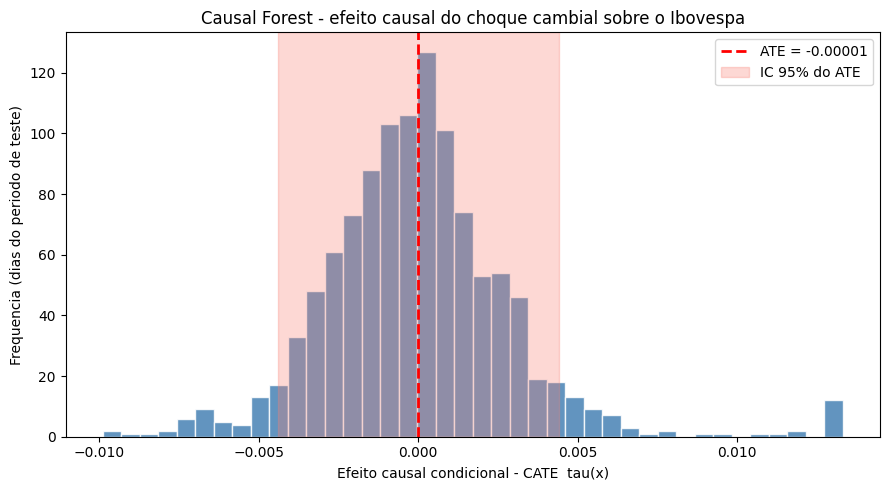


Reconstrucao preditiva (Y_hat = m0(X) + tau(X)*T):
  MAE=0.010466  RMSE=0.014889  R2=0.2423


In [5]:
# Causal Forest - CATE no teste, figura e reconstrucao preditiva
cate_test = cf_model.effect(X_cf_test)
cate_lb, cate_ub = cf_model.effect_interval(X_cf_test, alpha=0.05)

print("Distribuicao do CATE (teste):")
print(f"  min={cate_test.min():.6f}  mediana={np.median(cate_test):.6f}  max={cate_test.max():.6f}")
print(f"  desvio-padrao={cate_test.std():.6f}  % efeitos negativos={np.mean(cate_test < 0)*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(cate_test, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(cf_ate, color='red', linestyle='--', linewidth=2, label=f'ATE = {cf_ate:.5f}')
ax.axvspan(cf_ate_lb, cf_ate_ub, color='salmon', alpha=0.3, label='IC 95% do ATE')
ax.set_xlabel('Efeito causal condicional - CATE  tau(x)')
ax.set_ylabel('Frequencia (dias do periodo de teste)')
ax.set_title('Causal Forest - efeito causal do choque cambial sobre o Ibovespa')
ax.legend()
plt.tight_layout()
plt.savefig(str(FIGS_DIR / "cf_cate_distribuicao.png"), dpi=150, bbox_inches="tight")
plt.show()

# Reconstrucao preditiva para a tabela comparativa:
# Y_hat = m0(X) + tau(X) * T, com m0 = regressao do desfecho nos dias de controle do treino.
base_ctrl = GradientBoostingRegressor(random_state=42)
base_ctrl.fit(X_cf_train[T_cf_train == 0], y_cf_train[T_cf_train == 0])
y_cf_hat = base_ctrl.predict(X_cf_test) + cate_test * T_cf_test

cf_mae  = mean_absolute_error(y_cf_test, y_cf_hat)
cf_rmse = np.sqrt(mean_squared_error(y_cf_test, y_cf_hat))
cf_r2   = r2_score(y_cf_test, y_cf_hat)
print(f"\nReconstrucao preditiva (Y_hat = m0(X) + tau(X)*T):")
print(f"  MAE={cf_mae:.6f}  RMSE={cf_rmse:.6f}  R2={cf_r2:.4f}")


## Registro de Métricas

In [6]:
# Registra métricas do Causal Forest em data/metricas_comparativo.csv
registrar_metricas(
    'Causal Forest',
    r2_base=None,
    mae_base=None,
    r2_teste=round(float(cf_r2), 4),
    mae_teste=round(float(cf_mae), 6),
    rmse_teste=round(float(cf_rmse), 6),
    extras={
        'ate':    round(float(cf_ate), 6),
        'ate_lb': round(float(cf_ate_lb), 6),
        'ate_ub': round(float(cf_ate_ub), 6),
        'covariates': COVS_CF,
    }
)

print(f"Causal Forest — MAE: {cf_mae:.6f} | RMSE: {cf_rmse:.6f} | R2: {cf_r2:.4f}")
print(f"ATE: {cf_ate:.6f}  IC 95%: [{cf_ate_lb:.6f}, {cf_ate_ub:.6f}]")


[metricas_comparativo] 'Causal Forest' → metricas_comparativo.csv
Causal Forest — MAE: 0.010466 | RMSE: 0.014889 | R2: 0.2423
ATE: -0.000005  IC 95%: [-0.004410, 0.004399]


---

## CF1 — Tuning e Análises Causais

Random search amplo (N=150 por limiar) avaliado em holdout 2018–2019.
Métrica primária: **R-loss (Nie–Wager)**. Métrica secundária: R² de reconstrução.
Três limiares de tratamento (p70, p75, p80) para análise de robustez.

In [7]:
# ── Configuração do tuning CF1 ─────────────────────────────────────────────
SMOKE_MODE      = os.environ.get('CF_SMOKE', '0') == '1'
N_RANDOM_SEARCH = 8 if SMOKE_MODE else 150
FORCE_RETRAIN   = True   # True: refaz tudo | False: usa cache se existir
LIMIARES        = {'p70': 0.70, 'p75': 0.75, 'p80': 0.80}
RANDOM_SEED     = 42

CF_MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f"SMOKE_MODE={SMOKE_MODE} | N={N_RANDOM_SEARCH} | FORCE_RETRAIN={FORCE_RETRAIN}")
print(f"Cache: {CF_MODELS_DIR}")

SMOKE_MODE=False | N=150 | FORCE_RETRAIN=True
Cache: C:\Users\Lucao\Documentos\Dev\TCC\data\cf_models


In [8]:
def prepara_dados_por_limiar(percentil: float):
    """Prepara splits para um dado percentil. Limiar calculado SÓ no treino."""
    train_raw = pd.read_csv(str(DATA_DIR / 'causal_forest_train.csv'),
                            index_col=0, parse_dates=True)
    test_raw  = pd.read_csv(str(DATA_DIR / 'causal_forest_test.csv'),
                            index_col=0, parse_dates=True)
    limiar  = train_raw['br_dolar_diff'].abs().quantile(percentil)
    T_train = (train_raw['br_dolar_diff'].abs() >= limiar).astype(int).values
    T_test  = (test_raw['br_dolar_diff'].abs()  >= limiar).astype(int).values
    if abs(percentil - 0.75) < 1e-9:
        assert (T_train == train_raw['T_choque_dolar'].values).all(), \
            f"p75 divergiu do CSV original (limiar={limiar:.6f})"
    _TGT  = 'br_ibov_ret_log'
    _DROP = [_TGT, 'T_choque_dolar', 'br_dolar_diff']
    covs  = [c for c in train_raw.columns if c not in _DROP]
    X_full = train_raw[covs].values;  Y_full = train_raw[_TGT].values
    X_test_a = test_raw[covs].values; Y_test_a = test_raw[_TGT].values
    tune_mask = train_raw.index < VAL_SPLIT_DATE
    X_tune = X_full[tune_mask];  T_tune = T_train[tune_mask]; Y_tune = Y_full[tune_mask]
    X_val  = X_full[~tune_mask]; T_val  = T_train[~tune_mask];Y_val  = Y_full[~tune_mask]
    lbl = f"p{int(round(percentil*100)):02d}"
    print(f"  [{lbl}] limiar={limiar:.4f} | tune T=1:{T_tune.mean():.1%} "
          f"val T=1:{T_val.mean():.1%} teste T=1:{T_test.mean():.1%}")
    return (X_tune,T_tune,Y_tune, X_val,T_val,Y_val,
            X_full,T_train,Y_full, X_test_a,T_test,Y_test_a, limiar,covs)

In [9]:
def r_loss_holdout(tau_val, m_hat, e_hat, Y_val, T_val):
    """R-loss Nie–Wager: E[((Y-m(X)) - tau(X)*(T-e(X)))^2]"""
    return float(np.mean(((Y_val - m_hat) - tau_val*(T_val - e_hat))**2))

def r2_pred(tau_val, m_hat, Y_val, T_val):
    return float(r2_score(Y_val, m_hat + tau_val*T_val))

def _best_config(df):
    top20 = df.nsmallest(20, 'r_loss').copy()
    filt  = top20[top20['r2_pred'] >= top20['r2_pred'].median() - 0.02]
    if filt.empty: filt = top20
    return filt.sort_values(['r_loss','n_estimators']).iloc[0].to_dict()

def roda_random_search(nome, percentil, n_iter, seed=42):
    csv_p = CF_MODELS_DIR / f"random_search_{nome}.csv"
    cfg_p = CF_MODELS_DIR / f"best_config_{nome}.json"
    if not FORCE_RETRAIN and cfg_p.exists():
        print(f"[{nome}] Cache: {cfg_p.name}")
        with open(cfg_p, encoding='utf-8') as f: best = json.load(f)
        df_res = pd.read_csv(csv_p) if csv_p.exists() else pd.DataFrame()
        return best, df_res
    print(f"\n[{nome}] Random search N={n_iter}...")
    (X_tune,T_tune,Y_tune, X_val,T_val,Y_val,
     _,_,_, _,_,_, _,_) = prepara_dados_por_limiar(percentil)
    m_ext = GradientBoostingRegressor(n_estimators=200,max_depth=3,learning_rate=0.05,random_state=seed)
    t_ext = GradientBoostingClassifier(n_estimators=200,max_depth=3,learning_rate=0.05,random_state=seed)
    m_ext.fit(X_tune,Y_tune); t_ext.fit(X_tune,T_tune)
    m_hat = m_ext.predict(X_val)
    e_hat = np.clip(t_ext.predict_proba(X_val)[:,1], 0.02, 0.98)
    sp_cf = {
        'n_estimators': list(range(500,4001,100)),
        'min_samples_leaf': scipy.stats.randint(5,81),
        'max_depth': [None,6,8,10,14],
        'max_features': [None,'sqrt',0.5,0.7],
        'min_balancedness_tol': scipy.stats.uniform(0.30,0.20),
        'subforest_size': [2,4,8],
    }
    sp_nu = {'ny':[100,200,400],'dy':[2,3,5],'ly':[0.03,0.05,0.10]}
    cfgs  = list(ParameterSampler(sp_cf, n_iter=n_iter, random_state=seed))
    ncfgs = list(ParameterSampler(sp_nu, n_iter=n_iter, random_state=seed+1))
    rows  = []
    step  = max(1, n_iter//5)
    for i,(cfg,nc) in enumerate(zip(cfgs,ncfgs)):
        ny,dy,ly = int(nc['ny']),int(nc['dy']),float(nc['ly'])
        sub  = int(cfg['subforest_size'])
        nest = int(cfg['n_estimators'])
        # n_estimators deve ser divisivel por subforest_size
        if nest % sub != 0:
            nest = (nest // sub + 1) * sub
        try:
            cf = CausalForestDML(
                model_y=GradientBoostingRegressor(n_estimators=ny,max_depth=dy,learning_rate=ly,random_state=seed),
                model_t=GradientBoostingClassifier(n_estimators=ny,max_depth=dy,learning_rate=ly,random_state=seed),
                discrete_treatment=True, honest=True, random_state=seed,
                n_estimators=nest, min_samples_leaf=int(cfg['min_samples_leaf']),
                max_depth=cfg['max_depth'], max_features=cfg['max_features'],
                min_balancedness_tol=float(cfg['min_balancedness_tol']),
                subforest_size=sub,
            )
            cf.fit(Y=Y_tune,T=T_tune,X=X_tune)
            tau = cf.effect(X_val)
            rl  = r_loss_holdout(tau,m_hat,e_hat,Y_val,T_val)
            r2p = r2_pred(tau,m_hat,Y_val,T_val)
        except Exception as ex:
            print(f"  [{nome}] Config {i} falhou: {ex}")
            continue
        rows.append({'n_estimators':nest,
                     'min_samples_leaf':int(cfg['min_samples_leaf']),
                     'max_depth':str(cfg['max_depth']),
                     'max_features':str(cfg['max_features']),
                     'min_balancedness_tol':round(float(cfg['min_balancedness_tol']),4),
                     'subforest_size':sub, 'ny':ny,'dy':dy,'ly':ly,
                     'r_loss':rl,'r2_pred':r2p})
        if (i+1)%step==0:
            print(f"  [{nome}] {i+1}/{n_iter} melhor R-loss:{min(r['r_loss'] for r in rows):.6f}")
    if not rows:
        raise RuntimeError(f"[{nome}] Nenhuma config válida no random search.")
    df_res = pd.DataFrame(rows); df_res.to_csv(csv_p, index=False)
    br = _best_config(df_res)
    def _p(v):
        if v in ('None','nan','') or (isinstance(v,float) and np.isnan(v)): return None
        for t in [int,float]:
            try: return t(v)
            except: pass
        return v
    best = {'n_estimators':int(br['n_estimators']),'min_samples_leaf':int(br['min_samples_leaf']),
            'max_depth':_p(str(br['max_depth'])),'max_features':_p(str(br['max_features'])),
            'min_balancedness_tol':float(br['min_balancedness_tol']),'subforest_size':int(br['subforest_size']),
            'ny':int(br['ny']),'dy':int(br['dy']),'ly':float(br['ly']),
            'r_loss_val':round(br['r_loss'],6),'r2_pred_val':round(br['r2_pred'],4)}
    with open(cfg_p,'w',encoding='utf-8') as f: json.dump(best,f,indent=2)
    print(f"[{nome}] R-loss={best['r_loss_val']:.6f} R²={best['r2_pred_val']:.4f}")
    print(f"  CF: n_est={best['n_estimators']} msl={best['min_samples_leaf']} "
          f"depth={best['max_depth']} feat={best['max_features']} "
          f"bal={best['min_balancedness_tol']} sub={best['subforest_size']}")
    print(f"  Nuisance: n={best['ny']} d={best['dy']} lr={best['ly']}")
    return best, df_res

### Random Search por Limiar (p70, p75, p80)

In [10]:
print("="*60+"\nRandom search — p70\n"+"="*60)
best_p70, df_p70 = roda_random_search('p70', LIMIARES['p70'], N_RANDOM_SEARCH, RANDOM_SEED)
print("\nTop-5 p70 por R-loss:")
print(df_p70.nsmallest(5,'r_loss')[['n_estimators','min_samples_leaf','max_depth',
                                     'max_features','r_loss','r2_pred']].to_string(index=False))

Random search — p70

[p70] Random search N=150...
  [p70] limiar=0.0197 | tune T=1:28.1% val T=1:46.1% teste T=1:60.5%


c:\Users\Lucao\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 27 is smaller than n_iter=150. Running 27 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[p70] R-loss=0.000131 R²=0.1820
  CF: n_est=2104 msl=15 depth=10 feat=0.7 bal=0.3011 sub=8
  Nuisance: n=100 d=3 lr=0.1

Top-5 p70 por R-loss:
 n_estimators  min_samples_leaf max_depth max_features   r_loss  r2_pred
         2104                15        10          0.7 0.000131 0.182039
         2800                13        14         None 0.000131 0.179739
         2504                76        10         None 0.000131 0.188371
         2700                37      None          0.7 0.000131 0.184999
         3200                63        14          0.7 0.000131 0.185935


In [11]:
print("="*60+"\nRandom search — p75\n"+"="*60)
best_p75, df_p75 = roda_random_search('p75', LIMIARES['p75'], N_RANDOM_SEARCH, RANDOM_SEED)
print("\nTop-5 p75 por R-loss:")
print(df_p75.nsmallest(5,'r_loss')[['n_estimators','min_samples_leaf','max_depth',
                                     'max_features','r_loss','r2_pred']].to_string(index=False))

Random search — p75

[p75] Random search N=150...
  [p75] limiar=0.0229 | tune T=1:23.2% val T=1:39.6% teste T=1:55.9%


c:\Users\Lucao\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 27 is smaller than n_iter=150. Running 27 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[p75] R-loss=0.000132 R²=0.1783
  CF: n_est=2504 msl=76 depth=10 feat=None bal=0.3367 sub=8
  Nuisance: n=100 d=2 lr=0.03

Top-5 p75 por R-loss:
 n_estimators  min_samples_leaf max_depth max_features   r_loss  r2_pred
         2504                76        10         None 0.000132 0.178322
         3200                63        14          0.7 0.000132 0.178389
         2800                79         6          0.5 0.000132 0.180067
         2200                67         6          0.7 0.000133 0.177840
         1000                70         8          0.5 0.000133 0.179433


In [12]:
print("="*60+"\nRandom search — p80\n"+"="*60)
best_p80, df_p80 = roda_random_search('p80', LIMIARES['p80'], N_RANDOM_SEARCH, RANDOM_SEED)
print("\nTop-5 p80 por R-loss:")
print(df_p80.nsmallest(5,'r_loss')[['n_estimators','min_samples_leaf','max_depth',
                                     'max_features','r_loss','r2_pred']].to_string(index=False))

Random search — p80

[p80] Random search N=150...
  [p80] limiar=0.0270 | tune T=1:18.6% val T=1:31.9% teste T=1:50.2%


c:\Users\Lucao\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 27 is smaller than n_iter=150. Running 27 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[p80] R-loss=0.000132 R²=0.1867
  CF: n_est=2700 msl=37 depth=None feat=0.7 bal=0.3899 sub=4
  Nuisance: n=400 d=3 lr=0.1

Top-5 p80 por R-loss:
 n_estimators  min_samples_leaf max_depth max_features   r_loss  r2_pred
         2700                37      None          0.7 0.000132 0.186696
         1100                64         6          0.7 0.000132 0.185067
         2200                67         6          0.7 0.000132 0.184196
         2800                55      None         sqrt 0.000132 0.184786
         2504                76        10         None 0.000132 0.183013


### Refit Final e Avaliação no Teste (2020–2024)

In [13]:
def _build_cf(cfg):
    # Garante que n_estimators seja divisível por subforest_size
    nest = int(cfg['n_estimators']); sub = int(cfg['subforest_size'])
    if nest % sub != 0: nest = (nest // sub + 1) * sub
    my = GradientBoostingRegressor(n_estimators=cfg['ny'],max_depth=cfg['dy'],
                                   learning_rate=cfg['ly'],random_state=RANDOM_SEED)
    mt = GradientBoostingClassifier(n_estimators=cfg['ny'],max_depth=cfg['dy'],
                                    learning_rate=cfg['ly'],random_state=RANDOM_SEED)
    return CausalForestDML(model_y=my,model_t=mt,discrete_treatment=True,honest=True,
                           random_state=RANDOM_SEED,
                           n_estimators=nest,min_samples_leaf=cfg['min_samples_leaf'],
                           max_depth=cfg['max_depth'],max_features=cfg['max_features'],
                           min_balancedness_tol=cfg['min_balancedness_tol'],
                           subforest_size=sub)

def treina_e_avalia(nome, percentil, cfg):
    pkl_p = CF_MODELS_DIR / f"cf_final_{nome}.pkl"
    (_,_,_, _,_,_, X_tr,T_tr,Y_tr, X_te,T_te,Y_te, _,covs) = prepara_dados_por_limiar(percentil)
    if not FORCE_RETRAIN and pkl_p.exists():
        print(f"[{nome}] Carregando pkl: {pkl_p.name}")
        cf = joblib.load(pkl_p)
    else:
        print(f"[{nome}] Refitando em treino completo...")
        cf = _build_cf(cfg)
        cf.fit(Y=Y_tr, T=T_tr, X=X_tr)
        joblib.dump(cf, pkl_p, compress=3)
        print(f"[{nome}] Salvo: {pkl_p.name}")
    ate  = float(cf.ate(X_te))
    lb,ub = cf.ate_interval(X_te,alpha=0.05); lb,ub = float(lb),float(ub)
    cate = cf.effect(X_te)
    bm   = GradientBoostingRegressor(random_state=RANDOM_SEED)
    bm.fit(X_tr[T_tr==0], Y_tr[T_tr==0])
    Y_hat = bm.predict(X_te) + cate*T_te
    m_res = metricas(Y_te, Y_hat)
    print(f"  ATE={ate:.6f} IC=[{lb:.6f},{ub:.6f}]")
    print(f"  CATE med={np.median(cate):.6f} std={cate.std():.6f} neg={np.mean(cate<0)*100:.1f}%")
    print(f"  R²={m_res['r2']:.4f} MAE={m_res['mae']:.6f} RMSE={m_res['rmse']:.6f}")
    return {'cf':cf,'cate':cate,'ate':ate,'ate_lb':lb,'ate_ub':ub,
            'r2':m_res['r2'],'mae':m_res['mae'],'rmse':m_res['rmse'],
            'X_tr':X_tr,'T_tr':T_tr,'Y_tr':Y_tr,'X_te':X_te,'T_te':T_te,'Y_te':Y_te,'covs':covs}

resultados = {}
for nome, perc in LIMIARES.items():
    with open(CF_MODELS_DIR/f"best_config_{nome}.json",encoding='utf-8') as f: cfg=json.load(f)
    print(f"\n{'='*50}\n{nome.upper()}")
    resultados[nome] = treina_e_avalia(nome, perc, cfg)


P70
  [p70] limiar=0.0197 | tune T=1:28.1% val T=1:46.1% teste T=1:60.5%
[p70] Refitando em treino completo...
[p70] Salvo: cf_final_p70.pkl
  ATE=0.000801 IC=[-0.002489,0.004090]
  CATE med=0.000321 std=0.002408 neg=44.0%
  R²=0.1991 MAE=0.010540 RMSE=0.015308

P75
  [p75] limiar=0.0229 | tune T=1:23.2% val T=1:39.6% teste T=1:55.9%
[p75] Refitando em treino completo...
[p75] Salvo: cf_final_p75.pkl
  ATE=-0.000086 IC=[-0.002625,0.002453]
  CATE med=-0.000528 std=0.002227 neg=58.7%
  R²=0.2321 MAE=0.010509 RMSE=0.014990

P80
  [p80] limiar=0.0270 | tune T=1:18.6% val T=1:31.9% teste T=1:50.2%
[p80] Refitando em treino completo...
[p80] Salvo: cf_final_p80.pkl
  ATE=0.000186 IC=[-0.002855,0.003226]
  CATE med=-0.000124 std=0.001664 neg=53.0%
  R²=0.2008 MAE=0.010610 RMSE=0.015292


In [14]:
# Registra métricas dos 3 modelos
res75 = resultados['p75']
# Modelo principal (p75) — sobrescreve linha CF0 mantendo nome 'Causal Forest' para notebook 07
registrar_metricas('Causal Forest',
    r2_base=None, mae_base=None,
    r2_teste=round(res75['r2'],4), mae_teste=round(res75['mae'],6), rmse_teste=round(res75['rmse'],6),
    extras={'ate':round(res75['ate'],6),'ate_lb':round(res75['ate_lb'],6),
            'ate_ub':round(res75['ate_ub'],6),'cate_std':round(float(res75['cate'].std()),6),
            'covariates':res75['covs']})
for nome in ['p70','p80']:
    r = resultados[nome]
    registrar_metricas(f'Causal Forest ({nome})',
        r2_base=None,mae_base=None,
        r2_teste=round(r['r2'],4),mae_teste=round(r['mae'],6),rmse_teste=round(r['rmse'],6),
        extras={'ate':round(r['ate'],6),'ate_lb':round(r['ate_lb'],6),'ate_ub':round(r['ate_ub'],6)})
print(f"\np70: R²={resultados['p70']['r2']:.4f} ATE={resultados['p70']['ate']:+.6f}")
print(f"p75: R²={resultados['p75']['r2']:.4f} ATE={resultados['p75']['ate']:+.6f}  <- principal")
print(f"p80: R²={resultados['p80']['r2']:.4f} ATE={resultados['p80']['ate']:+.6f}")

[metricas_comparativo] 'Causal Forest' → metricas_comparativo.csv
[metricas_comparativo] 'Causal Forest (p70)' → metricas_comparativo.csv
[metricas_comparativo] 'Causal Forest (p80)' → metricas_comparativo.csv

p70: R²=0.1991 ATE=+0.000801
p75: R²=0.2321 ATE=-0.000086  <- principal
p80: R²=0.2008 ATE=+0.000186


## Análises Causais — CF1 (p75 final)

As análises abaixo usam exclusivamente o modelo final com limiar p75.
p70/p80 aparecem apenas na tabela de robustez.

CATE (CF1 p75): min=-0.005341 med=-0.000528 max=0.006202 std=0.002227 neg=58.7%


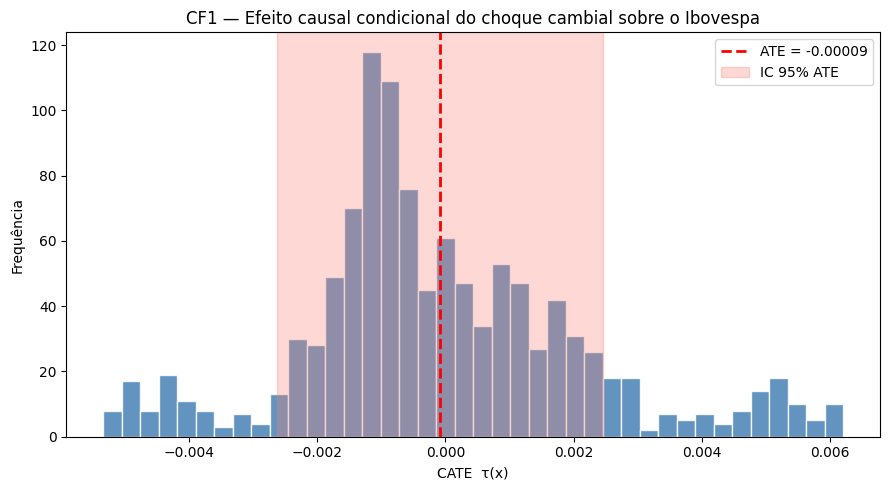

Salvo: cf_cate_distribuicao.png


In [15]:
# ── Distribuição global do CATE ───────────────────────────────────────────
r   = resultados['p75']
cf  = r['cf']; cate = r['cate']; ate = r['ate']; lb = r['ate_lb']; ub = r['ate_ub']
print(f"CATE (CF1 p75): min={cate.min():.6f} med={np.median(cate):.6f} "
      f"max={cate.max():.6f} std={cate.std():.6f} neg={np.mean(cate<0)*100:.1f}%")
fig,ax = plt.subplots(figsize=(9,5))
ax.hist(cate,bins=40,color='steelblue',edgecolor='white',alpha=0.85)
ax.axvline(ate,color='red',linestyle='--',linewidth=2,label=f'ATE = {ate:.5f}')
ax.axvspan(lb,ub,color='salmon',alpha=0.3,label='IC 95% ATE')
ax.set_xlabel('CATE  τ(x)'); ax.set_ylabel('Frequência'); ax.legend()
ax.set_title('CF1 — Efeito causal condicional do choque cambial sobre o Ibovespa')
plt.tight_layout()
plt.savefig(str(FIGS_DIR/"cf_cate_distribuicao.png"),dpi=150,bbox_inches="tight"); plt.show()
print("Salvo: cf_cate_distribuicao.png")

In [16]:
# ── BLP — Best Linear Predictor (Chernozhukov) ───────────────────────────
r = resultados['p75']
X_te,T_te,Y_te,cate = r['X_te'],r['T_te'],r['Y_te'],r['cate']
n = len(Y_te); m_blp = np.zeros(n); e_blp = np.zeros(n)
for tr_i,vl_i in TimeSeriesSplit(n_splits=5).split(X_te):
    mf = GradientBoostingRegressor(n_estimators=200,max_depth=3,learning_rate=0.05,random_state=RANDOM_SEED)
    tf = GradientBoostingClassifier(n_estimators=200,max_depth=3,learning_rate=0.05,random_state=RANDOM_SEED)
    mf.fit(X_te[tr_i],Y_te[tr_i]); tf.fit(X_te[tr_i],T_te[tr_i])
    m_blp[vl_i] = mf.predict(X_te[vl_i])
    e_blp[vl_i] = tf.predict_proba(X_te[vl_i])[:,1]
e_blp = np.clip(e_blp,0.02,0.98)
H = ((T_te - e_blp)/(e_blp*(1-e_blp)))*(Y_te - m_blp)
res_blp = sm.OLS(H, sm.add_constant(cate)).fit()
b0,b1 = res_blp.params
ci    = res_blp.conf_int()   # ndarray shape (2,2) quando input é numpy
ci_b1 = ci[1]                # linha do slope (índice 1)
pv    = res_blp.pvalues[1]
print("BLP (Chernozhukov):")
print(f"  beta0={b0:.4f} (esperado aprox 0)  beta1={b1:.4f} (calibracao aprox 1)")
print(f"  IC 95% beta1=[{ci_b1[0]:.4f},{ci_b1[1]:.4f}]  p-valor={pv:.4f}")
print("  -> heterogeneidade detectavel" if pv<0.05 else "  -> heterogeneidade nao sign. a 5%")
print(res_blp.summary().tables[1])
_BLP = {'b0':float(b0),'b1':float(b1),'ci_b1':[float(ci_b1[0]),float(ci_b1[1])],'pval':float(pv)}

BLP (Chernozhukov):
  beta0=-0.0089 (esperado aprox 0)  beta1=76.6717 (calibracao aprox 1)
  IC 95% beta1=[61.7583,91.5850]  p-valor=0.0000
  -> heterogeneidade detectavel
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0089      0.017     -0.527      0.599      -0.042       0.024
x1            76.6717      7.601     10.087      0.000      61.758      91.585


  Decil  1: ATE=-0.003863  IC=[-0.007139,-0.000588] *
  Decil  2: ATE=-0.001844  IC=[-0.004122,+0.000434]  
  Decil  3: ATE=-0.001307  IC=[-0.003423,+0.000809]  
  Decil  4: ATE=-0.001013  IC=[-0.003020,+0.000995]  
  Decil  5: ATE=-0.000726  IC=[-0.002679,+0.001227]  
  Decil  6: ATE=-0.000251  IC=[-0.002483,+0.001981]  
  Decil  7: ATE=+0.000375  IC=[-0.002066,+0.002815]  
  Decil  8: ATE=+0.001115  IC=[-0.001439,+0.003669]  
  Decil  9: ATE=+0.001996  IC=[-0.000732,+0.004724]  
  Decil 10: ATE=+0.004379  IC=[+0.001057,+0.007702] *


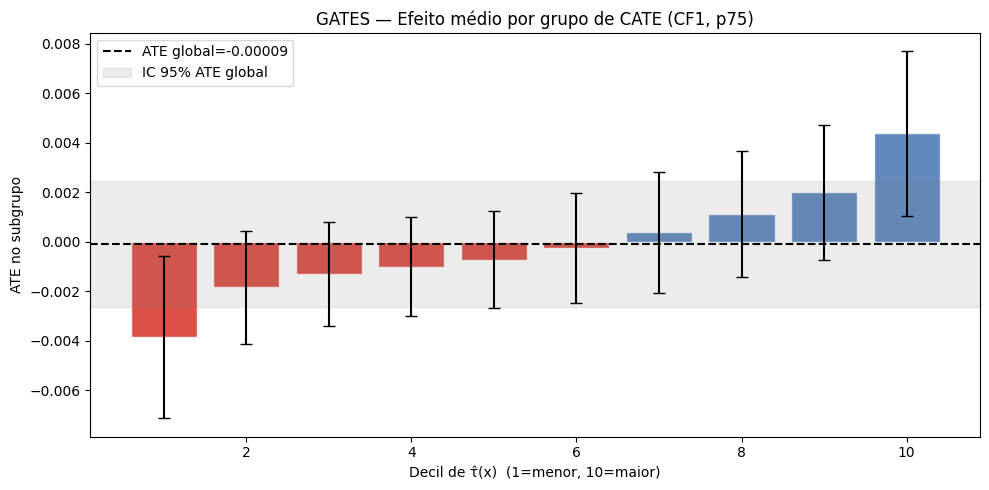

Salvo: cf_gates.png


In [17]:
# ── GATES — ATE por decis do CATE ────────────────────────────────────────
r = resultados['p75']
cf,cate,X_te = r['cf'],r['cate'],r['X_te']
idx_ord = np.argsort(cate); sz = len(cate)//10
g_ate,g_lb,g_ub,g_med = [],[],[],[]
for k in range(10):
    s,e = k*sz, (k+1)*sz if k<9 else len(cate)
    ik  = idx_ord[s:e]; Xk = X_te[ik]
    ak  = float(cf.ate(Xk)); lk,uk = cf.ate_interval(Xk,alpha=0.05)
    g_ate.append(ak); g_lb.append(float(lk)); g_ub.append(float(uk)); g_med.append(float(np.median(cate[ik])))
    sig = "*" if (lk>0 or uk<0) else " "
    print(f"  Decil {k+1:2d}: ATE={ak:+.6f}  IC=[{lk:+.6f},{uk:+.6f}] {sig}")
fig,ax = plt.subplots(figsize=(10,5))
decis = list(range(1,11))
yerr  = np.array([[a-l,u-a] for a,l,u in zip(g_ate,g_lb,g_ub)]).T
ax.bar(decis,g_ate,yerr=yerr,capsize=4,
       color=['#d73027' if v<0 else '#4575b4' for v in g_ate],edgecolor='white',alpha=0.85)
ax.axhline(r['ate'],color='black',linestyle='--',lw=1.5,label=f"ATE global={r['ate']:.5f}")
ax.axhspan(r['ate_lb'],r['ate_ub'],color='gray',alpha=0.15,label='IC 95% ATE global')
ax.set_xlabel('Decil de τ̂(x)  (1=menor, 10=maior)'); ax.set_ylabel('ATE no subgrupo')
ax.set_title('GATES — Efeito médio por grupo de CATE (CF1, p75)'); ax.legend()
plt.tight_layout()
plt.savefig(str(FIGS_DIR/"cf_gates.png"),dpi=150,bbox_inches="tight"); plt.show()
print("Salvo: cf_gates.png")
_GATES = {'decis':decis,'ate':g_ate,'lb':g_lb,'ub':g_ub,'cate_med':g_med}

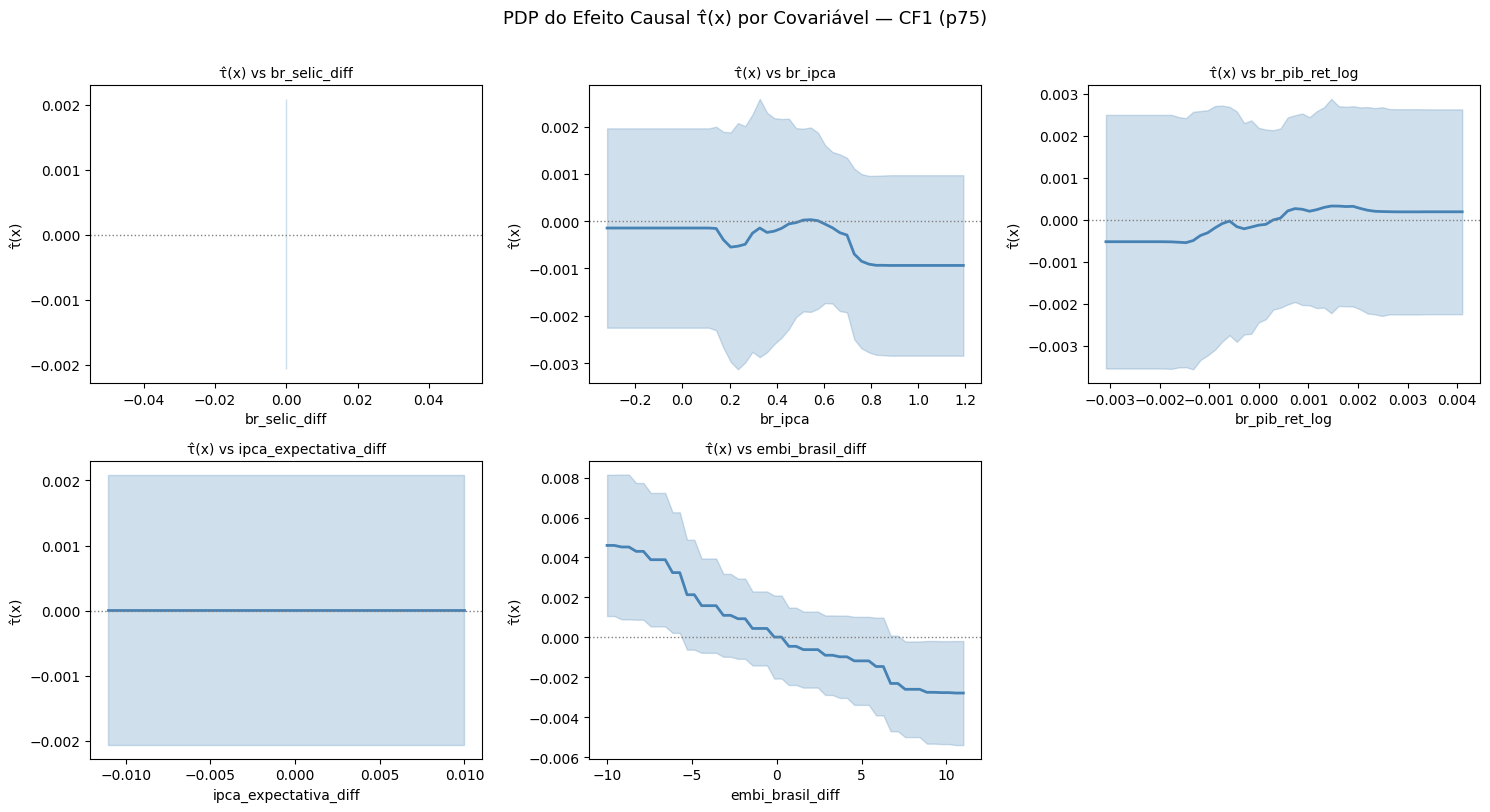

Salvo: cf_pdp_tau.png
  br_selic_diff: range=[+0.000011,+0.000011] ampl=0.000000 mono=S
  br_ipca: range=[-0.000936,+0.000031] ampl=0.000967 mono=N
  br_pib_ret_log: range=[-0.000545,+0.000329] ampl=0.000874 mono=N
  ipca_expectativa_diff: range=[+0.000011,+0.000011] ampl=0.000000 mono=S
  embi_brasil_diff: range=[-0.002792,+0.004602] ampl=0.007394 mono=S


In [18]:
# ── PDP do τ(x) — heterogeneidade por covariável ─────────────────────────
r = resultados['p75']; cf,X_te,covs = r['cf'],r['X_te'],r['covs']
fig,axes = plt.subplots(2,3,figsize=(15,8)); axes = axes.flatten()
pdp_sum = {}
for j,cov in enumerate(covs):
    grid = np.linspace(np.percentile(X_te[:,j],5),np.percentile(X_te[:,j],95),50)
    Xg   = np.tile(np.median(X_te,axis=0),(50,1)); Xg[:,j] = grid
    tg   = cf.effect(Xg); tl,tu = cf.effect_interval(Xg,alpha=0.05)
    ax   = axes[j]
    ax.plot(grid,tg,color='steelblue',lw=2)
    ax.fill_between(grid,tl,tu,alpha=0.25,color='steelblue')
    ax.axhline(0,color='gray',ls=':',lw=1)
    ax.set_xlabel(cov,fontsize=10); ax.set_ylabel('τ̂(x)',fontsize=10)
    ax.set_title(f'τ̂(x) vs {cov}',fontsize=10)
    pdp_sum[cov] = {'min':float(tg.min()),'max':float(tg.max()),
                    'range':float(tg.max()-tg.min()),
                    'mono':bool(np.all(np.diff(tg)>=0) or np.all(np.diff(tg)<=0))}
axes[5].set_visible(False)
plt.suptitle('PDP do Efeito Causal τ̂(x) por Covariável — CF1 (p75)',fontsize=13,y=1.01)
plt.tight_layout()
plt.savefig(str(FIGS_DIR/"cf_pdp_tau.png"),dpi=150,bbox_inches="tight"); plt.show()
print("Salvo: cf_pdp_tau.png")
for cov,s in pdp_sum.items():
    print(f"  {cov}: range=[{s['min']:+.6f},{s['max']:+.6f}] ampl={s['range']:.6f} mono={'S' if s['mono'] else 'N'}")
_PDP = pdp_sum

feature_importances_ nativo do CausalForestDML utilizado.


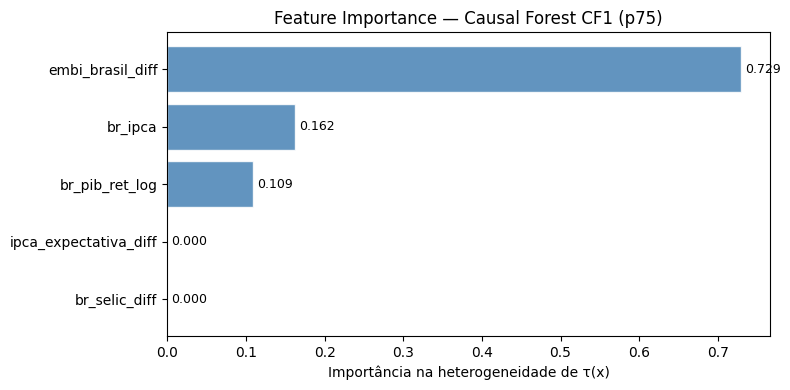

Salvo: cf_feature_importance.png

Importâncias (decrescente):
  embi_brasil_diff: 0.7294
  br_ipca: 0.1618
  br_pib_ret_log: 0.1088
  br_selic_diff: 0.0000
  ipca_expectativa_diff: 0.0000


In [19]:
# ── Feature importance do τ(x) ────────────────────────────────────────────
r = resultados['p75']; cf,covs = r['cf'],r['covs']
try:
    fi = cf.feature_importances_
    print("feature_importances_ nativo do CausalForestDML utilizado.")
except AttributeError:
    from sklearn.inspection import permutation_importance as _pi
    pi = _pi(cf,r['X_te'],r['cate'],n_repeats=10,random_state=RANDOM_SEED)
    fi = pi.importances_mean; print("Permutation importance (fallback).")
fi_df = pd.DataFrame({'feature':covs,'importance':fi}).sort_values('importance')
fig,ax = plt.subplots(figsize=(8,4))
bars = ax.barh(fi_df['feature'],fi_df['importance'],color='steelblue',edgecolor='white',alpha=0.85)
ax.set_xlabel('Importância na heterogeneidade de τ(x)')
ax.set_title('Feature Importance — Causal Forest CF1 (p75)')
ax.bar_label(bars,fmt='%.3f',padding=3,fontsize=9)
plt.tight_layout()
plt.savefig(str(FIGS_DIR/"cf_feature_importance.png"),dpi=150,bbox_inches="tight"); plt.show()
print("Salvo: cf_feature_importance.png")
print("\nImportâncias (decrescente):")
for _,row in fi_df.sort_values('importance',ascending=False).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")
_FI = fi_df.sort_values('importance',ascending=False)[['feature','importance']].values.tolist()

 99%|===================| 1102/1117 [00:44<00:00]        

SHAP nativo CausalForestDML.


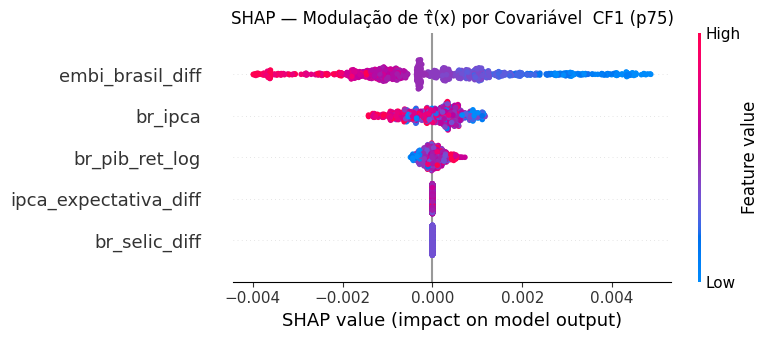

Salvo: cf_shap_summary.png


In [20]:
# ── SHAP do τ(x) ──────────────────────────────────────────────────────────
r = resultados['p75']; cf,X_te,cate,covs = r['cf'],r['X_te'],r['cate'],r['covs']
_proxy = False
try:
    sv_dict = cf.shap_values(X_te)
    outer   = next(iter(sv_dict.values()))
    sv      = next(iter(outer.values()))
    if hasattr(sv,'values'): sv = sv.values
    print("SHAP nativo CausalForestDML.")
except Exception as ex:
    print(f"shap_values nativo falhou ({ex}). Usando proxy GBR.")
    prx = GradientBoostingRegressor(n_estimators=300,max_depth=3,random_state=RANDOM_SEED)
    prx.fit(X_te,cate)
    sv = shap.TreeExplainer(prx).shap_values(X_te); _proxy = True
shap.summary_plot(sv,X_te,feature_names=covs,show=False,plot_type='dot')
suffix = " (proxy GBR sobre τ̂)" if _proxy else ""
plt.title(f"SHAP — Modulação de τ̂(x) por Covariável  CF1 (p75){suffix}")
plt.tight_layout()
plt.savefig(str(FIGS_DIR/"cf_shap_summary.png"),dpi=150,bbox_inches="tight"); plt.show()
print("Salvo: cf_shap_summary.png")
if _proxy: print("NOTA: proxy SHAP — registrar na legenda da figura no LaTeX.")
_SHAP_PROXY = _proxy

### Robustez do Tratamento — p70, p75, p80

In [21]:
# ── Tabela de robustez ────────────────────────────────────────────────────
rows_r = []
for nome,perc in LIMIARES.items():
    tr  = pd.read_csv(str(DATA_DIR/'causal_forest_train.csv'),index_col=0,parse_dates=True)
    te  = pd.read_csv(str(DATA_DIR/'causal_forest_test.csv'), index_col=0,parse_dates=True)
    lim = tr['br_dolar_diff'].abs().quantile(perc)
    ptr = (tr['br_dolar_diff'].abs()>=lim).mean(); pte = (te['br_dolar_diff'].abs()>=lim).mean()
    with open(CF_MODELS_DIR/f"best_config_{nome}.json",encoding='utf-8') as f: bc=json.load(f)
    res = resultados[nome]
    rows_r.append({'Limiar':nome,'limiar':f"{lim:.4f}",'prev_train':f"{ptr:.1%}",
                   'prev_test':f"{pte:.1%}",'R-loss val':f"{bc['r_loss_val']:.6f}",
                   'R² val':f"{bc['r2_pred_val']:.4f}",'ATE':f"{res['ate']:+.6f}",
                   'IC 95%':f"[{res['ate_lb']:+.4f},{res['ate_ub']:+.4f}]",
                   'R² teste':f"{res['r2']:.4f}",'MAE':f"{res['mae']:.6f}",'RMSE':f"{res['rmse']:.6f}"})
df_rob = pd.DataFrame(rows_r)
print("Tabela de robustez (→ tab:cf_robustez no LaTeX):")
print(df_rob.to_string(index=False))

Tabela de robustez (→ tab:cf_robustez no LaTeX):
Limiar limiar prev_train prev_test R-loss val R² val       ATE            IC 95% R² teste      MAE     RMSE
   p70 0.0197      30.0%     60.5%   0.000131 0.1820 +0.000801 [-0.0025,+0.0041]   0.1991 0.010540 0.015308
   p75 0.0229      25.0%     55.9%   0.000132 0.1783 -0.000086 [-0.0026,+0.0025]   0.2321 0.010509 0.014990
   p80 0.0270      20.0%     50.2%   0.000132 0.1867 +0.000186 [-0.0029,+0.0032]   0.2008 0.010610 0.015292


In [22]:
# ── Bloco para notas_edicao.md ────────────────────────────────────────────
with open(CF_MODELS_DIR/"best_config_p75.json",encoding='utf-8') as f: cfg75=json.load(f)
r75 = resultados['p75']; c75 = r75['cate']
print("="*70)
print("COPIAR PARA notas_edicao.md  ## Causal Forest — CF1")
print("="*70)
print(f"\n### 1. Configuração final (p75, random search N={N_RANDOM_SEARCH})")
print(f"CausalForestDML(n_estimators={cfg75['n_estimators']}, min_samples_leaf={cfg75['min_samples_leaf']},")
print(f"  max_depth={cfg75['max_depth']}, max_features={repr(cfg75['max_features'])},")
print(f"  min_balancedness_tol={cfg75['min_balancedness_tol']}, subforest_size={cfg75['subforest_size']},")
print(f"  model_y/t=GradientBoosting(n_est={cfg75['ny']},d={cfg75['dy']},lr={cfg75['ly']}))")
print(f"R-loss holdout={cfg75['r_loss_val']:.6f}  R²_pred holdout={cfg75['r2_pred_val']:.4f}")
print(f"\n### 2. ATE e CATE no teste")
print(f"ATE={r75['ate']:.6f}  IC=[{r75['ate_lb']:.6f},{r75['ate_ub']:.6f}]  distinto de zero: {'SIM' if (r75['ate_lb']>0 or r75['ate_ub']<0) else 'NAO'}")
print(f"CATE: min={c75.min():.6f}  med={np.median(c75):.6f}  max={c75.max():.6f}  std={c75.std():.6f}  neg={np.mean(c75<0)*100:.1f}%")
print(f"Reconstrução: R²={r75['r2']:.4f}  MAE={r75['mae']:.6f}  RMSE={r75['rmse']:.6f}")
print(f"\n### 3. BLP")
print(f"β₀={_BLP['b0']:.4f}  β₁={_BLP['b1']:.4f}  IC=[{_BLP['ci_b1'][0]:.4f},{_BLP['ci_b1'][1]:.4f}]  p={_BLP['pval']:.4f}")
print(f"\n### 4. GATES (10 decis)")
for k,(a,l,u) in enumerate(zip(_GATES['ate'],_GATES['lb'],_GATES['ub']),1):
    print(f"  Decil {k:2d}: {a:+.6f} [{l:+.4f},{u:+.4f}]")
print(f"\n### 5. Feature importance (decrescente)")
for name,imp in _FI: print(f"  {name}: {imp:.4f}")
print(f"\n### 6. Tabela de robustez p70/p75/p80")
print(df_rob.to_string(index=False))
print("\n### 7. Figuras")
print("  cf_cate_distribuicao.png → fig:cf_cate")
print("  cf_gates.png             → fig:cf_gates")
print("  cf_pdp_tau.png           → fig:cf_pdp_tau")
print("  cf_feature_importance.png→ fig:cf_feat_imp")
print(f"  cf_shap_summary.png      → fig:cf_shap{'  (proxy GBR)' if _SHAP_PROXY else ''}")

COPIAR PARA notas_edicao.md  ## Causal Forest — CF1

### 1. Configuração final (p75, random search N=150)
CausalForestDML(n_estimators=2504, min_samples_leaf=76,
  max_depth=10, max_features=None,
  min_balancedness_tol=0.3367, subforest_size=8,
  model_y/t=GradientBoosting(n_est=100,d=2,lr=0.03))
R-loss holdout=0.000132  R²_pred holdout=0.1783

### 2. ATE e CATE no teste
ATE=-0.000086  IC=[-0.002625,0.002453]  distinto de zero: NAO
CATE: min=-0.005341  med=-0.000528  max=0.006202  std=0.002227  neg=58.7%
Reconstrução: R²=0.2321  MAE=0.010509  RMSE=0.014990

### 3. BLP
β₀=-0.0089  β₁=76.6717  IC=[61.7583,91.5850]  p=0.0000

### 4. GATES (10 decis)
  Decil  1: -0.003863 [-0.0071,-0.0006]
  Decil  2: -0.001844 [-0.0041,+0.0004]
  Decil  3: -0.001307 [-0.0034,+0.0008]
  Decil  4: -0.001013 [-0.0030,+0.0010]
  Decil  5: -0.000726 [-0.0027,+0.0012]
  Decil  6: -0.000251 [-0.0025,+0.0020]
  Decil  7: +0.000375 [-0.0021,+0.0028]
  Decil  8: +0.001115 [-0.0014,+0.0037]
  Decil  9: +0.001996 [-